In [1]:
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [2]:
source('../utilities/functions/pathway-heatmaps-modified.R')

In [3]:
celltypes <- c(
  "HSPC Stem",
  "HSPC Multi",
  "LMPP",
  "CLP",
  "CMP Core",
  "CMP Gran",
  "MEP",
  "Pre Prog Ery",
  "Prog Ery",
  "Prog Ery Prolif",
  "Pre Mono Core",
  "Pre Mono Prolif",
  "Prog B Pre",
  "Prog B",
  "Pre B Heavy",
  "Pre B Light",
  "Pre B Prolif",
  "Prog DC cDC",
  "Prog DC pDC"
)


In [4]:
# Load bone marrow data files
pretx_v_healthy <- read.csv('../../data/figure-inputs/l3-fgsea_all_results/fgsea_all_results_bmmc_PreTx_vs_Healthy.csv') %>% 
    filter(celltype %in% celltypes)
ei_v_healthy <- read.csv('../../data/figure-inputs/l3-fgsea_all_results/fgsea_all_results_bmmc_EI_vs_Healthy.csv') %>%
    filter(celltype %in% celltypes)
bm_90d_v_healthy <- read.csv('../../data/figure-inputs/l3-fgsea_all_results/fgsea_all_results_bmmc_ASCT90d_vs_Healthy.csv') %>%
    filter(celltype %in% celltypes)
bm_1y_v_healthy <- read.csv('../../data/figure-inputs/l3-fgsea_all_results/fgsea_all_results_bmmc_ASCT1y_vs_Healthy.csv') %>%
    filter(celltype %in% celltypes)
bm_2y_v_healthy <- read.csv('../../data/figure-inputs/l3-fgsea_all_results/fgsea_all_results_bmmc_ASCT2y_vs_Healthy.csv') %>%
    filter(celltype %in% celltypes)


# Create list of datasets and comparison names

data_list <- list(pretx_v_healthy, ei_v_healthy, bm_90d_v_healthy, bm_1y_v_healthy, bm_2y_v_healthy)
bm_comparison_names <- c("PreTx *", "EI *", "ASCT90d *", "ASCT1y *", "ASCT2y *")

In [5]:
pathways <- c(
    "IRF3 ENCODE",
    "INTERFERON GAMMA RESPONSE",
    "INTERFERON ALPHA RESPONSE",
    "EPSTEIN-BARR VIRUS INFECTION",
    "TGF-BETA SIGNALING",
    "TNF-ALPHA SIGNALING VIA NF-KB",
    "HYPOXIA",
    "OXIDATIVE PHOSPHORYLATION",
    "FOXM1 ENCODE"
)

Filtered to 19 cell types that have data across datasets



Reordered cell types based on L3 to L1 hierarchy



Selected 9 pathways from combined data



[1] "IRF3 ENCODE"                   "INTERFERON GAMMA RESPONSE"    
[3] "INTERFERON ALPHA RESPONSE"     "EPSTEIN-BARR VIRUS INFECTION" 
[5] "TGF-BETA SIGNALING"            "TNF-ALPHA SIGNALING VIA NF-KB"
[7] "HYPOXIA"                       "OXIDATIVE PHOSPHORYLATION"    
[9] "FOXM1 ENCODE"                 


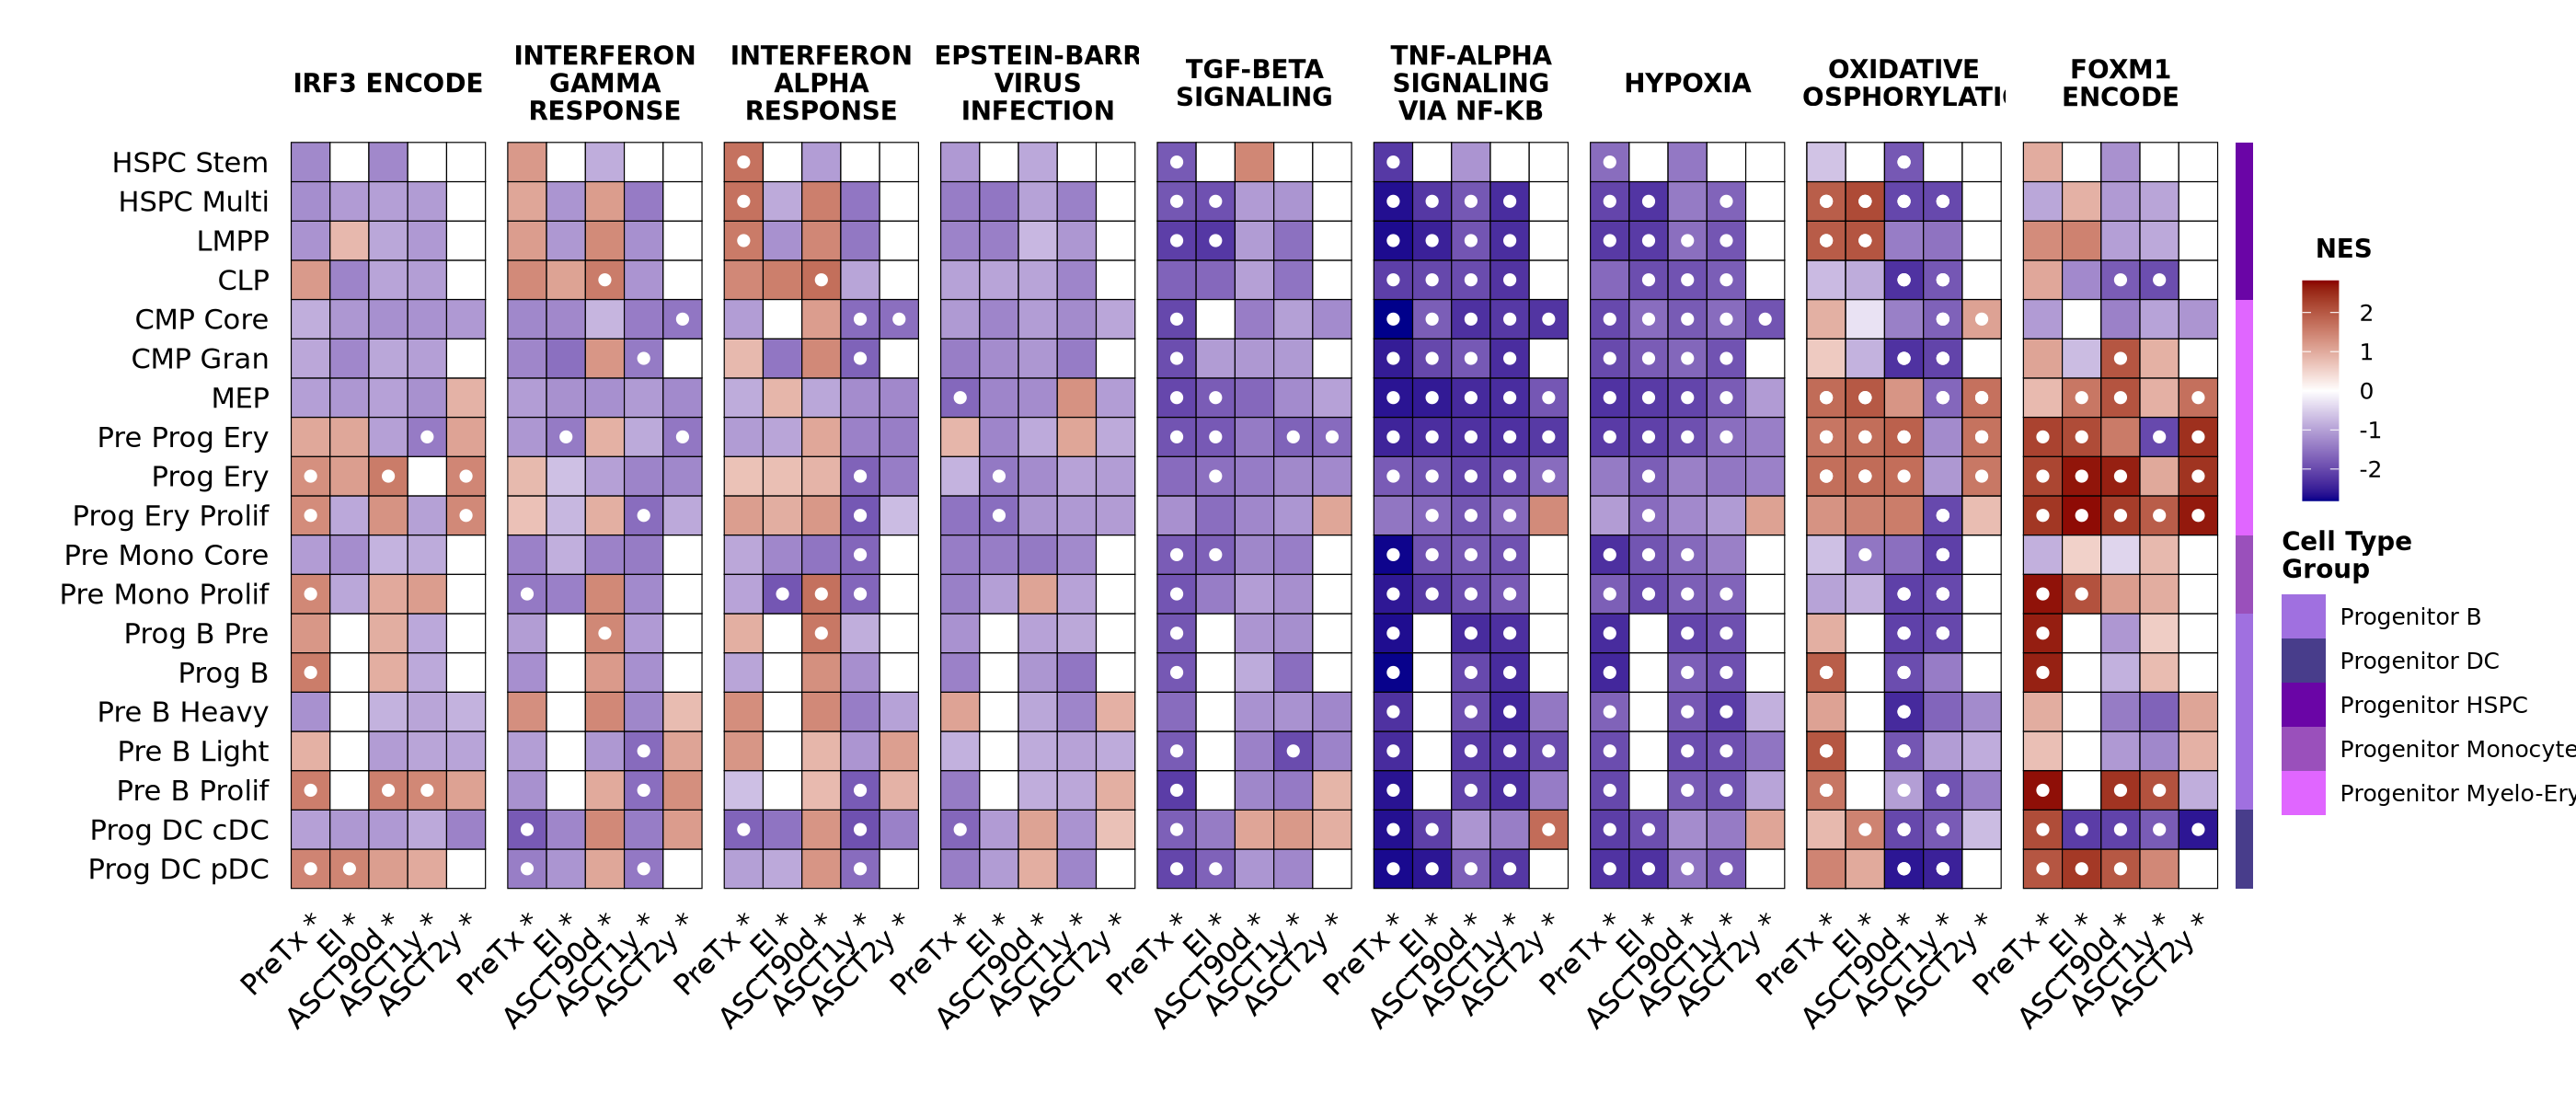

In [6]:
plot_width <- 14
plot_height <- 6
plot_dpi <- 200

# faceted heatmap for bone marrow
p <- create_faceted_pathway_heatmap(
  data_list = data_list,
  comparison_names = bm_comparison_names,
  pathway_method = "manual",
  celltypes = rev(celltypes),
  pathway_list = pathways,
  max_label_length = 30,
  plot_width = plot_width,
  plot_height = plot_height,
  facet_ncol = 9,
  strip_text_size = 10,
  axis_text_x_size = 11,
  axis_text_y_size = 11,
)

p

In [7]:
ggsave("fig_4b.pdf", plot = p, width = plot_width, height = plot_height, dpi = plot_dpi, device = cairo_pdf, path = "../../data/figure-outputs/figure-4")